<a href="https://colab.research.google.com/github/harjasjolly-create/trading-suggestion-project/blob/main/hypothesis_verifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import yfinance as yf
import pandas as pd
data = yf.download("AAPL", period="54wk", interval="1wk")
import seaborn as sns

/tmp/ipykernel_571/2807584764.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="54wk", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [3]:
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 55 entries, 2025-08-04 to 2026-08-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   54 non-null     float64
 1   (High, AAPL)    54 non-null     float64
 2   (Low, AAPL)     54 non-null     float64
 3   (Open, AAPL)    54 non-null     float64
 4   (Volume, AAPL)  55 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.6 KB


**BUILDING CHART_ANALYSIS MODEL **

In [4]:
close,high,low,open,volume=df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],df.iloc[:,3],df.iloc[:,4]


**creating simple moving average(sma)** somewhat an average position vector but of closing prices(average closing value fo a batch

In [5]:
sma=close.rolling(window=20).mean()#taking batch of 20 weeks at a time, shifting by 1
sma


,Close
,AAPL
Date,
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN
2025-09-22,NaN


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'SMA')]

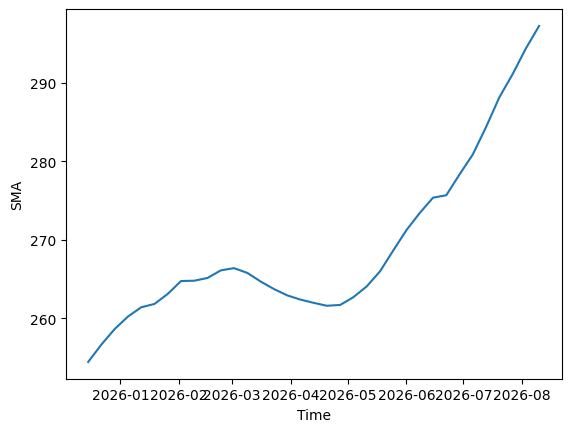

In [6]:
#visualizing sma
sns.lineplot(sma.dropna()).set(xlabel='Time',ylabel='SMA')

**creating average true range(14 candle) (ATR14)**

In [7]:
from os import name
tr1=high-low
#now we need prev timeframe's close value
close_prev=close.shift(1)#since we need prev week closing
tr2=(high-close_prev).abs()
tr3=(low-close_prev).abs()
values=pd.concat([tr1,tr2,tr3],axis=1)
tr_final=values.max(axis=1)
atr14=tr_final.rolling(window=14).mean()
atr14.rename('ATR14',inplace=True)

atr14#so basically average max volatility over 14cweeks batches

,ATR14
Date,
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN
2025-09-22,NaN
2025-09-29,NaN


**EMA**

Building ema so as to incorporate recent trends more weighted than past trends , for better accuracy, ill be using ema20 and ema50 with assumption that ema20 moving faaster than ema 50 means bullish trend

In [8]:
ema20=close.ewm(span=20,adjust=False).mean()
ema50=close.ewm(span=50,adjust=False).mean()#weight decreases as day goes more in past
ema_signal=(ema20-ema50)/close#dividing by closing price so as to create a ratio relative to stock price for better classification model training across different stocks
ema_signal

,Close
,AAPL
Date,
2025-08-04,0.000000
2025-08-11,0.000605
2025-08-18,0.000205
2025-08-25,0.000908
2025-09-01,0.003236
2025-09-08,0.004054
2025-09-15,0.007072
2025-09-22,0.011634


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'EMA')]

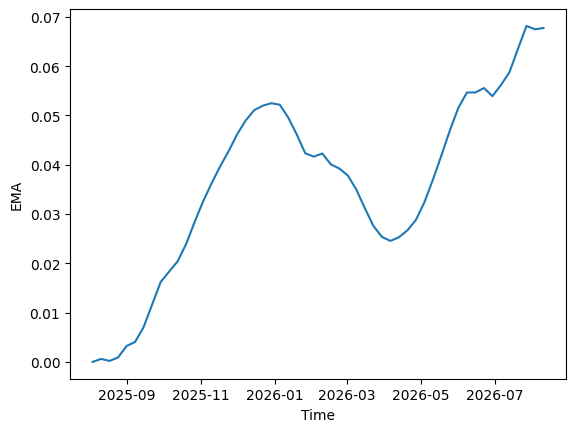

In [9]:
sns.lineplot(ema_signal).set(xlabel='Time',ylabel='EMA')

**Building RSI i.e relative strength of buyers to sellers**, cosidering rsi>50 as bullish,<50 as bearish ,>70 as overbought,<30 as oversold , basically it tells what poercentage of price movements is bullish

[Text(0.5, 0, 'Time'), Text(0, 0.5, 'RSI')]

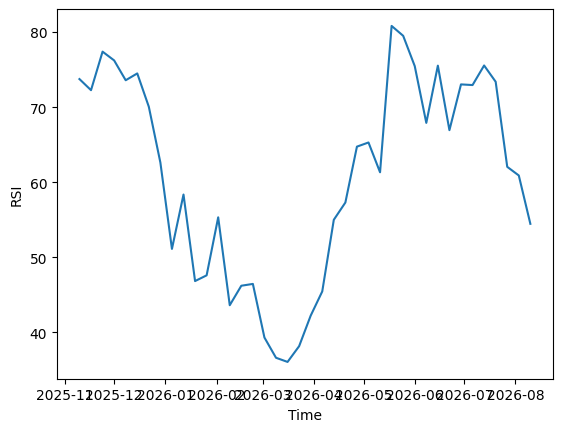

In [10]:
delta=close.diff()# calculating price change
gain=delta.clip(lower=0).rolling(14).mean()
loss=-delta.clip(upper=0).rolling(14).mean()
rs=gain/loss
#normalising rs from 0 ro 100 instead of 0 to infinity
rsi=100-100/(1+rs)
sns.lineplot(rsi).set(xlabel='Time',ylabel='RSI')

note: each rolling code requires actual entires so initial and final value might be considered nan output, as im currently using 54 week data, we can increase it to create a better model

**Building support resistance levels**

firstly, building swing highs and swing lows thats local highs and lows over 7 week windows

In [11]:
df["is_swing_high"]=(high==high.rolling(7,center=True).max())
df["is_swing_low"]=(low==low.rolling(7,center=True).min())
swing_high=df.loc[df['is_swing_high'],('High','AAPL')]
swing_low=df.loc[df["is_swing_low"],('Low','AAPL')]


now, we need to cluster swing highs and lows that are almost nearby so as to create the support and resistance levels but the zone width to consider two lows in same cluster is dependent on the volatility of stock  so well use atr for this ans assume a safe zone width of atr*0.5 so the lows can be within 50% of volatility at that time and hence considered the same lows and if 2 lows fall into a cluster, then that will be the support

In [12]:
atr_multiplier=0.5

In [13]:
support_df=pd.concat([swing_low,atr14],axis=1).dropna()
support_df


,"(Low, AAPL)",ATR14
Date,,
2026-01-19,242.759230,10.319514
2026-03-30,245.072652,13.001508
2026-06-22,273.514106,15.877309


In [14]:
#converting to list of dictionaries so that i can pop without any index error and also itll increase speed as dataframes are slow in delecting rows and looping over them (though they are fast at simukltaneous math)
swinglows=support_df.to_dict('records')#using record so that it created dictionary liost row wise and not column wise(record and row are same things)
swinglows


[{('Low', 'AAPL'): 242.75922990826072, 'ATR14': 10.319513776357127},
 {('Low', 'AAPL'): 245.07265167866177, 'ATR14': 13.001507824148828},
 {('Low', 'AAPL'): 273.51410564235374, 'ATR14': 15.8773094479282}]

In [15]:
true_support=[]
while len(swinglows)>0:
  base_item = swinglows.pop(0)
  base_price = base_item[('Low', 'AAPL')]
  base_atr = base_item['ATR14']
  zone_width=atr_multiplier*base_atr
  potential_support=[base_price]
  remaining=[]
  for rest in swinglows:
    if abs(rest[('Low', 'AAPL')]-base_price)<=zone_width:
      potential_support.append(rest[('Low', 'AAPL')])
    else:
      remaining.append(rest)
  swinglows=remaining
  if len(potential_support)>=2:
    avg_support=sum(potential_support)/len(potential_support)
    true_support.append(avg_support)


In [16]:
true_support

[243.91594079346123]

In [17]:
#now coding true_resistance

In [18]:
resistance_df=pd.concat([swing_high,atr14],axis=1).dropna()
resistance_df

,"(High, AAPL)",ATR14
Date,,
2025-12-01,287.836540,11.305386
2026-02-02,280.147456,10.899125
2026-06-08,317.126504,14.625509


In [19]:
swinghighs=resistance_df.to_dict('records')
true_resistance=[]
while len(swinghighs)>0:
  top_item = swinghighs.pop(0)
  top_price = top_item[('High', 'AAPL')]
  top_atr = top_item['ATR14']
  zone_width=atr_multiplier*top_atr
  potential_resistance=[top_price]
  remaining=[]
  for rest in swinghighs:
    if abs(rest[('High', 'AAPL')]-top_price)<=zone_width:
      potential_resistance.append(rest[('High', 'AAPL')])
    else:
      remaining.append(rest)
  swinghighs=remaining
  if len(potential_resistance)>=2:

    avg_resistance=sum(potential_resistance)/len(potential_resistance)
    true_resistance.append(avg_resistance)




In [20]:
true_resistance

[]

**finding y for further modelling**

In [21]:
# ill be using triple barrier method for stock_execution score and alpha for stock_alpha score so as to check strength relative to benchmark
#ill use s&p 500 returns as benchmark


**triple barrier**

In [22]:

stock_data=pd.concat([close,atr14],axis=1)
#using name upper amnd lower barrier instead of target and stop loss so as to justify the name triple barrier;)

In [23]:
stock_data['upper_barrier']=stock_data[('Close', 'AAPL')]+stock_data['ATR14']*2
stock_data['lower_barrier']=stock_data[('Close', 'AAPL')]-stock_data['ATR14']*1
stock_data.sample(5)

,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier
Date,,,,
2026-03-23,248.356796,12.658870,273.674536,235.697926
2026-01-26,258.775635,10.385235,279.546104,248.390400
2025-08-11,230.737656,NaN,NaN,NaN
2025-09-08,233.208527,NaN,NaN,NaN
2026-04-06,260.015991,13.547553,287.111097,246.468438


In [24]:
#lets use time barrier of 2 weeks
stock_data["shifted_close"]=stock_data[('Close', 'AAPL')].shift(-2)


In [25]:
#now giving score of +1,-1 and 0 accordingly
import numpy as np
conditions=[(stock_data["shifted_close"]>=stock_data['upper_barrier']),(stock_data["shifted_close"]<=stock_data['lower_barrier'])]
choices=[1,-1]
stock_data["exec_score"]=np.select(conditions,choices,default=0)
stock_data.sample(5)


,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier,shifted_close,exec_score
Date,,,,,,
2025-08-25,231.285614,NaN,NaN,NaN,233.208527,0
2025-09-22,254.519806,NaN,NaN,NaN,244.367310,0
2025-09-29,257.070374,NaN,NaN,NaN,251.361481,0
2025-11-10,271.670532,11.043420,293.757372,260.627112,278.093018,0
2026-03-16,247.548233,12.956741,273.461715,234.591492,255.464111,0


**now the benchmark comparison that is alpha score**

In [26]:
snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
snp_close=pd.DataFrame(snp_data).iloc[:,0]
snp_close.info()

/tmp/ipykernel_571/520086488.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
DatetimeIndex: 55 entries, 2025-08-04 to 2026-08-17
Series name: ('Close', '^GSPC')
Non-Null Count  Dtype  
--------------  -----  
54 non-null     float64
dtypes: float64(1)
memory usage: 880.0 bytes


In [27]:
#now comparison
#ill be using 2 week timeframe for return comparison
stock_data['stock_return_2wk']=(stock_data['shifted_close']-stock_data[('Close', 'AAPL')])/stock_data[('Close', 'AAPL')]
snp_data['shifted_close']=snp_close.shift(-2)
stock_data['snp_return_2wk']=(snp_data['shifted_close']-snp_data[('Close', '^GSPC')])/snp_data[('Close', '^GSPC')]
stock_data['aplha']=stock_data['stock_return_2wk']-stock_data['snp_return_2wk']
#considering a buffer oif 0.5% so as to remove buffer as if alpha is 0.2% more than benchmark, it isnt really a great winner but similiar to 0 so just a noise so well consider it as 0
conditions=[(stock_data['aplha']>0.005),stock_data['aplha']<0.005]
choices=[1,-1]
stock_data["alpha_score"]=np.select(conditions,choices,default=0)
stock_data['alpha_score'].head()

,alpha_score
Date,
2025-08-04,-1
2025-08-11,-1
2025-08-18,1
2025-08-25,-1
2025-09-01,-1


**now creating a score based on support resitance , considering if close is within 1%of nearest support or resistance, then well consider the actual +-1 score else iot wopnt really matter and hence 0**


In [31]:
#true_support
#true_resistance
#finding closest resistance and support
import numpy as np
def find_nearest_support(value):
  if not true_support:
    return np.nan
  min_dist=(abs(true_support[0]-value))
  nearest_support=true_support[0]
  for i in true_support:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_support=i
  return nearest_support
def find_nearest_resistance(value):
  if not true_resistance:
    return np.nan
  min_dist=(abs(true_resistance[0]-value))
  nearest_resistance=true_resistance[0]
  for i in true_resistance:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_resistance=i
  return nearest_resistance
stock_data["nearest resistance"]=0
stock_data["nearest support"]=0
stock_data["nearest resistance"]=stock_data[('Close', 'AAPL')].apply(find_nearest_resistance)
stock_data["nearest support"]=stock_data[('Close', 'AAPL')].apply(find_nearest_support)





In [32]:
#now if stock is in 1% zone of nearest support that would mean upside potential so floor_ceiling_score=+1 and -1 for similar with nearest resistance else 0
conditions=[(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest support'])/stock_data['nearest support']<=0.01),(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest resistance'])/stock_data['nearest resistance']<=0.01)]
choices=[+1,-1]
stock_data['floor_ceiling_score']=np.select(conditions,choices,default=0)
stock_data['floor_ceiling_score'].sample(5)


,floor_ceiling_score
Date,
2026-04-27,0
2025-11-10,0
2026-06-08,0
2026-02-09,0
2025-09-15,1


getting company fundamnetaks form yahoo finance as earlier ome thats stockanaysis stopped me because of some cloudware wall stuff, basically they are not letting me scrape the data;(

In [78]:
def get_fundamentals(ticker_symbol):
    stock = yf.Ticker(ticker_symbol)
    data = stock.info

    fundamentals = {
        'PE_Ratio': data.get('trailingPE', 0),
        'Forward_PE': data.get('forwardPE', 0),




        'PEG_Ratio': data.get('trailingPegRatio', data.get('pegRatio', 0)),


        'ROE': data.get('returnOnEquity', 0),



        'Price_to_Book': data.get('priceToBook', 0),
        'Revenue_Growth_YoY': data.get('revenueGrowth', 0),
        'Earnings_Growth_YoY': data.get('earningsGrowth', 0),
        'Profit_Margin': data.get('profitMargins', 0),
        'Debt_to_Equity': data.get('debtToEquity', 0)
    }

    return fundamentals


metrics = get_fundamentals("AAPL")
print(f"PE Ratio: {metrics['PE_Ratio']}")
print(f"PEG Ratio: {metrics['PEG_Ratio']}")
print(f"Return on Equity: {metrics['ROE'] * 100}%")
print(f"Debt to Equity: {metrics['Debt_to_Equity']/100}")
de_ratio=metrics['Debt_to_Equity']/100
roe=metrics['ROE']*100
peg_ratio=metrics['PEG_Ratio']
pe_ratio=metrics['PE_Ratio']


PE Ratio: 35.08496
PEG Ratio: 2.4668
Return on Equity: 148.75101%
Debt to Equity: 0.78445


**pe score** currently setting thresholds but will use avg pe_ratio of past years to get the relative score which is more accurate but will do that later on as im getting this year data alone, ill try finding eps of past years and then divide by that years stock price to get the pe_ratios of those years

In [80]:

conditions=[(pe_ratio<=25),(25<pe_ratio<=30),(pe_ratio>30)]
choices=[1,0,-1]
pe_score=np.select(conditions,choices,default=0)
pe_score

array(-1)

**now finding peg score**

In [68]:

if peg_ratio<1:
  peg_score=1
elif 1<peg_ratio<2:
  peg_score=0
else:
  peg_score=-1
#used standard threshold for peg overvalued or undervalued
print(peg_score)

-1


**roe score using standard roe>20% roe<10% criteria**

In [69]:
if roe>=20:
  roe_score=+1
elif roe<=10:
  roe_score=-1
else:
  roe_score=0
roe_score


1

**debt/equity score using d/e<0.5 as safe adn d/e>1.5 as unsafe and in between moderate**

In [70]:
if de_ratio<=0.5:
  de_score=+1
elif de_ratio>=1.5:
  de_score=-1
else:
  de_score=0
de_score

0

for now i am averaging these scores to get **avg_fundamental_score**
we can later add optimal weights to each score if needeed but presently imassuming all to be equally important
---



In [73]:
avg_fundamental_score=(pe_score+peg_score+de_score+roe_score)/4
avg_fundamental_score

0.0

**now calculating sentiment score taht is basically score based on news headlines**

In [74]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 10.1 MB/s eta 0:00:00


In [75]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
web=requests.get('https://finance.yahoo.com/quote/AAPL/$0',headers=headers).text
response=BeautifulSoup(web,'lxml')
news=response.find_all('h3',class_='clamp yf-28d2hc')
news_list=[i.text for i in news]
news_list

['Trump admin. urges Apple not to purchase Chinese memory chips, but this presents a problem',
 'Apple (AAPL) Could Be 21% Above Fair Value On Premium iPhone And AI Push',
 'Apple vs. CoreWeave: Comparing Revenue Trends Between a Stable Tech Giant and a Rapidly Growing AI Neocloud',
 "Trump Wanted Advanced Tech Made in America, Tim Cook Brought Mac Mini Production to Texas: 'Thank You' for the $600 Billion Commitment, Says Howard Lutnick",
 'Micron Reclaims $1,000 Amid Fresh Memory Momentum: Jim Cramer Says MU Stock Can ‘Double Again’',
 'Micron and Western Digital Shares Are Soaring, What You Need To Know',
 'Review & Preview: Chips Aren’t Enough',
 'Financial Advisors Love Warren Buffett, but They Don’t Always Agree With Him',
 'Sandisk, Micron, Coherent, Boeing, Apple, Amazon, and More Stocks That Explain Today’s Market',
 'Micron Stock Closes Above $1,000 After Key Move by Trump Administration',
 'Apple Changes App Tracking Rules in Europe']

In [76]:
news_score_list=[]
for item in news_list:
  news_score=analyzer.polarity_scores(item)['compound']#just got to kniow that this gives 4 oparameters, neutral,negatuve,positive and theuir overall avg thats compoiund in -1 to 1 range
  news_score_list.append(news_score)
sentiment_score=np.mean(news_score_list)
sentiment_score


np.float64(0.2442181818181818)

#presently i am using normal average on news scores but technically i should have used exponenytisl average as recent news matter more buty will see that later for better model